# Phân Tích Khám Phá Dữ Liệu (Exploratory Data Analysis - EDA)
## Dự Án: Dự Đoán Khách Hàng Rời Bỏ (Customer Churn Prediction)
**Người Thực Hiện:** Nguyễn Lâm Anh (LA)

**Mục Tiêu Phân Tích:**
1. Khám phá cấu trúc, kích thước, đặc trưng và kiểu dữ liệu của tập dữ liệu huấn luyện.
2. Đánh giá tỷ lệ và mức độ mất cân bằng lớp của biến mục tiêu `Churn`.
3. Phân tích phân phối của các biến số (`tenure`, `MonthlyCharges`, `TotalCharges`) và kiểm tra các giá trị ngoại lai (outliers).
4. Phân tích phân phối của các biến phân loại bao gồm nhân khẩu học, các loại dịch vụ đăng ký và thông tin thanh toán.
5. Thực hiện phân tích hai biến (Bivariate Analysis) để tìm ra các yếu tố (số lượng và phân loại) có ảnh hưởng mạnh mẽ nhất đến quyết định rời mạng của khách hàng.
6. Thực hiện các kiểm định giả thuyết thống kê (t-test, Chi-square) để khẳng định ý nghĩa thống kê của các mối liên hệ.
7. Đề xuất các phương án kỹ nghệ đặc trưng (Feature Engineering) có giá trị cao cho việc huấn luyện mô hình ở bước tiếp theo.

---
*Lưu ý: Theo yêu cầu của nhóm, mỗi cell code trong notebook này là hoàn toàn độc lập và tự chứa đầy đủ các câu lệnh import/tải dữ liệu để có thể chạy riêng lẻ mà không bị lỗi.*

In [1]:
# Khai báo các thư viện cần thiết cho toàn bộ Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cấu hình giao diện vẽ đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print("Thư viện được tải thành công!")

Thư viện được tải thành công!


### 1. Tổng Quan về Tập Dữ Liệu (Dataset Overview)
Để bắt đầu, chúng ta tải tập dữ liệu huấn luyện `train.csv` từ thư mục `data/` và kiểm tra các thuộc tính cơ bản:
- **Kích thước dữ liệu:** Số lượng quan sát (dòng) và số lượng biến (cột).
- **Kiểu dữ liệu:** Đảm bảo các đặc trưng dạng số và phân loại được nhận diện đúng kiểu dữ liệu trong pandas.
- **Dữ liệu khuyết thiếu (Missing values):** Xác định sự thiếu hụt dữ liệu trong từng cột để lên kế hoạch xử lý (imputation).
- **Dữ liệu trùng lặp (Duplicate rows):** Phát hiện và loại bỏ các dòng bị trùng lặp nếu có.

In [2]:
# Cell độc lập: Tải dữ liệu và phân tích tổng quan
import pandas as pd
import numpy as np

# Tải tập dữ liệu huấn luyện từ thư mục dữ liệu dùng chung
train_path = "../data/train.csv"
df = pd.read_csv(train_path)

# Hiển thị thông tin cơ bản
print(f"Kích thước tập dữ liệu huấn luyện: {df.shape[0]:,} dòng, {df.shape[1]} cột.\n")
print("--- 5 dòng đầu tiên của tập dữ liệu ---")
display(df.head())

print("\n--- Kiểu dữ liệu của các cột ---")
print(df.dtypes)

print("\n--- Số lượng giá trị khuyết thiếu (Null/NaN) ---")
print(df.isnull().sum())

print("\n--- Số dòng trùng lặp trong dữ liệu ---")
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")

Kích thước tập dữ liệu huấn luyện: 594,194 dòng, 21 cột.

--- 5 dòng đầu tiên của tập dữ liệu ---


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



--- Kiểu dữ liệu của các cột ---
id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

--- Số lượng giá trị khuyết thiếu (Null/NaN) ---
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
Stream

Số dòng trùng lặp: 0


### 2. Phân Tích Biến Mục Tiêu (Target Variable Analysis - `Churn`)
Biến mục tiêu của chúng ta là `Churn`, đại diện cho việc khách hàng có rời bỏ dịch vụ viễn thông hay không (`Yes` hoặc `No`).
Phân tích biến mục tiêu giúp chúng ta:
1. Xác định chính xác tỷ lệ rời mạng trong tập dữ liệu.
2. Nhận biết mức độ mất cân bằng lớp (Class Imbalance). Đây là thông tin cực kỳ quan trọng vì nếu tập dữ liệu mất cân bằng nghiêm trọng, mô hình học máy có xu hướng dự đoán lớp đa số (không rời mạng) tốt hơn lớp thiểu số (rời mạng). Khi đó, các chỉ số đánh giá như **F1-Score** hay **ROC-AUC** sẽ đáng tin cậy hơn **Accuracy** (độ chính xác tổng thể).

--- Thống kê chi tiết biến mục tiêu Churn ---
Churn = 'No': 460,377 khách hàng (77.48%)
Churn = 'Yes': 133,817 khách hàng (22.52%)


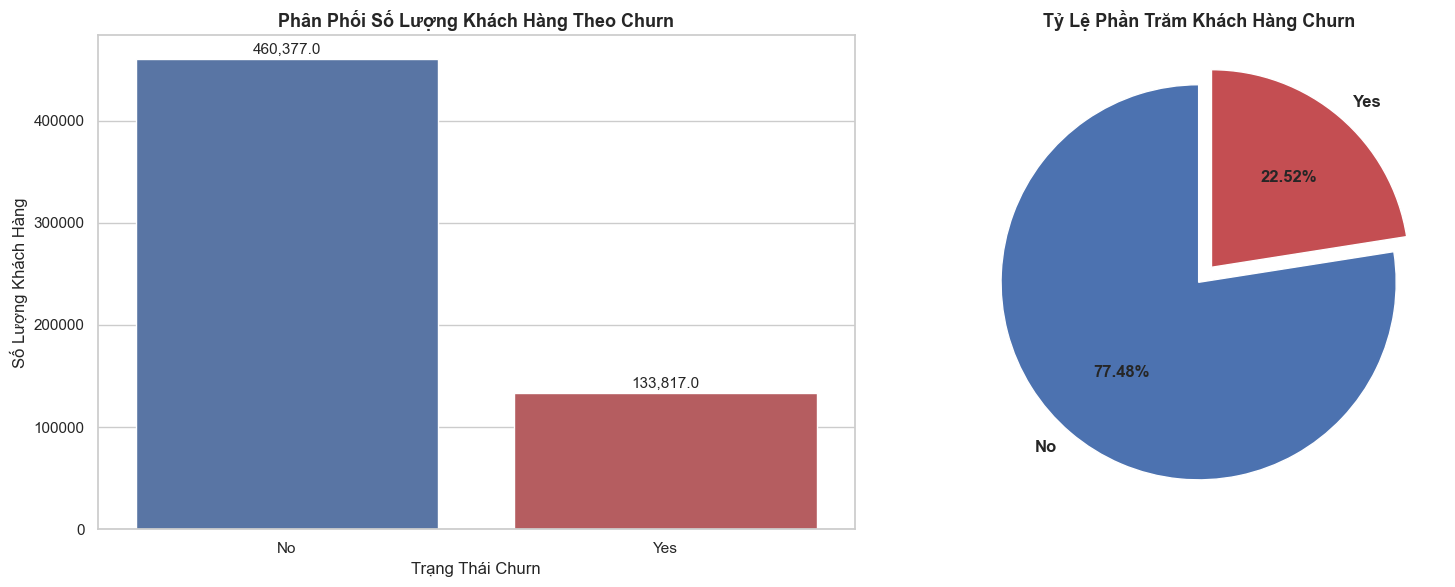

In [3]:
# Cell độc lập: Phân tích biến mục tiêu Churn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tải tập dữ liệu
df = pd.read_csv("../data/train.csv")

# Tính toán số lượng và tỷ lệ phần trăm
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("--- Thống kê chi tiết biến mục tiêu Churn ---")
for idx, (count, pct) in enumerate(zip(churn_counts, churn_percentages)):
    print(f"Churn = '{churn_counts.index[idx]}': {count:,} khách hàng ({pct:.2f}%)")

# Vẽ biểu đồ trực quan hóa
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ cột (Countplot)
sns.countplot(x='Churn', data=df, palette=['#4C72B0', '#C44E52'], ax=ax[0])
ax[0].set_title('Phân Phối Số Lượng Khách Hàng Theo Churn', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Trạng Thái Churn')
ax[0].set_ylabel('Số Lượng Khách Hàng')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].text(p.get_x() + p.get_width()/2., height + 5000, f'{height:,}', ha="center", fontsize=11)

# 2. Biểu đồ tròn (Pie chart)
ax[1].pie(churn_percentages, labels=churn_percentages.index, autopct='%1.2f%%', 
        startangle=90, colors=['#4C72B0', '#C44E52'], explode=[0, 0.1],
        textprops={'fontsize': 12, 'weight': 'bold'})
ax[1].set_title('Tỷ Lệ Phần Trăm Khách Hàng Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Phân Tích Các Đặc Trưng Dạng Số (Numerical Features Analysis)
Tập dữ liệu có 3 đặc trưng dạng số chính phản ánh mức độ gắn kết và chi tiêu của khách hàng:
- `tenure`: Số tháng khách hàng đã sử dụng dịch vụ của nhà mạng.
- `MonthlyCharges`: Số tiền khách hàng thanh toán hàng tháng (USD).
- `TotalCharges`: Tổng số tiền khách hàng đã thanh toán tích lũy cho nhà mạng (USD).

Chúng ta sẽ tiến hành phân tích:
- **Thống kê mô tả:** Các giá trị trung bình (Mean), trung vị (Median/50%), giá trị lớn nhất (Max), nhỏ nhất (Min), và độ lệch chuẩn.
- **Phân phối tần suất (Histogram & KDE):** Xem xét dạng phân phối của biến số, phát hiện độ lệch (Skewness). Nếu phân phối bị lệch nặng (như `TotalCharges`), việc áp dụng các biến đổi toán học như Log hoặc Box-Cox có thể giúp ích cho mô hình tuyến tính hoặc mạng neural.
- **Biểu đồ hộp (Boxplot):** Nhận diện trực quan các giá trị ngoại lai (outliers) có khả năng gây nhiễu cho mô hình học máy.

--- Thống kê mô tả các đặc trưng số ---


,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000



--- Độ lệch (Skewness) của các đặc trưng số ---
tenure: 0.0631
MonthlyCharges: -0.2895
TotalCharges: 0.9092


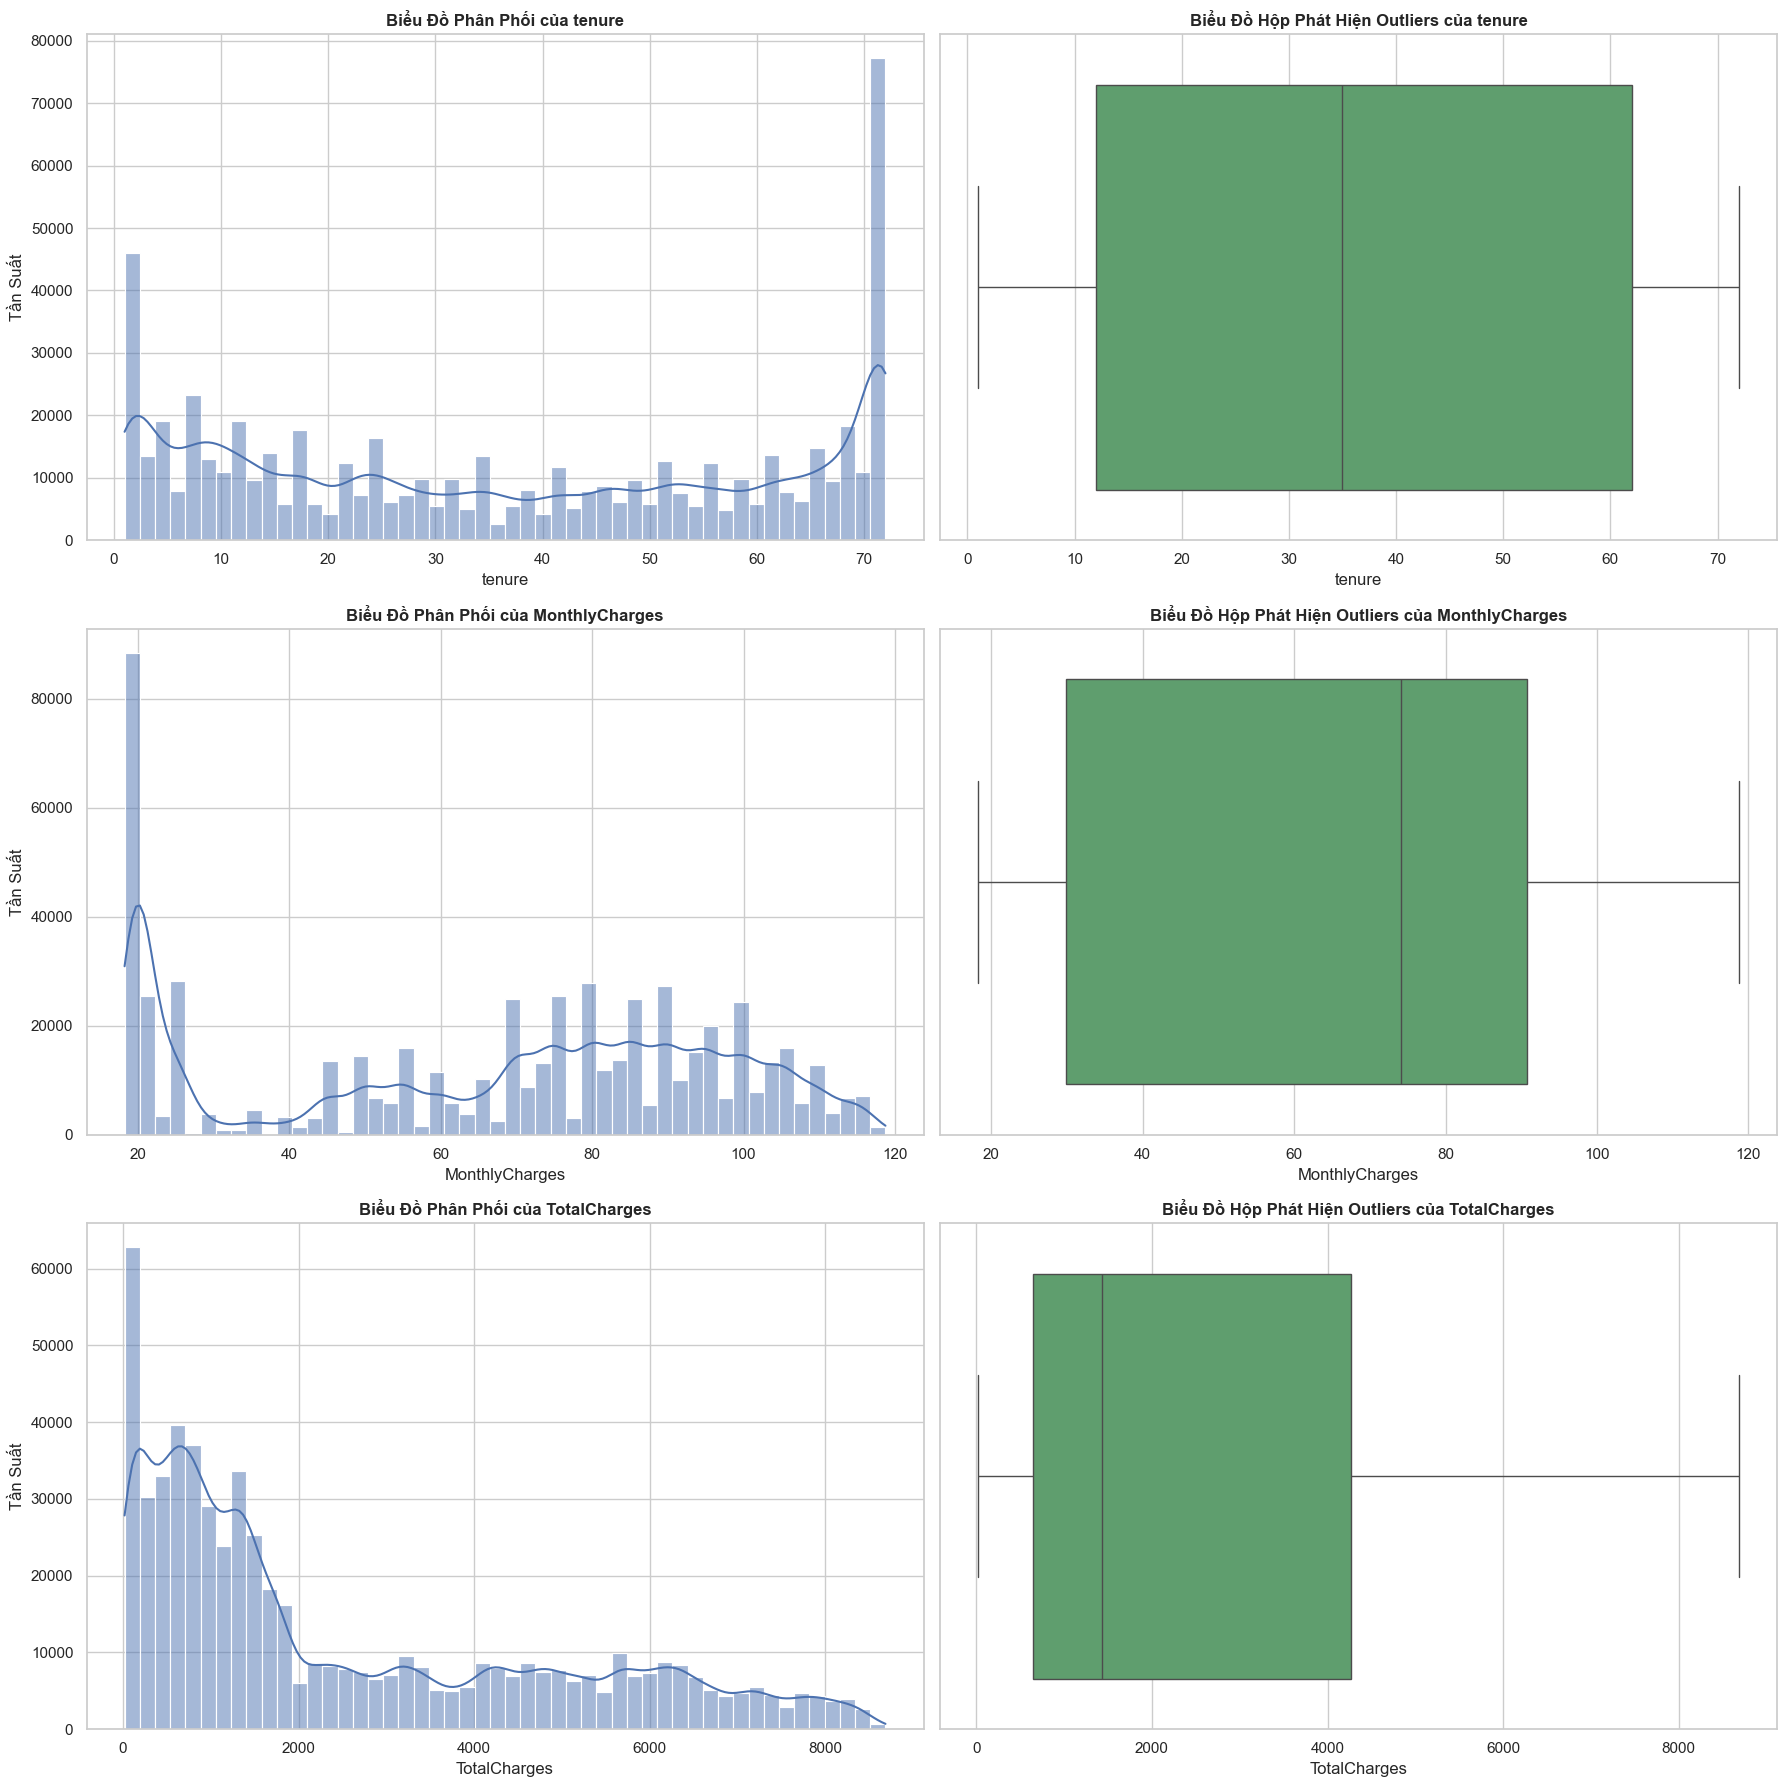

In [4]:
# Cell độc lập: Phân tích các đặc trưng dạng số
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. Thống kê mô tả
print("--- Thống kê mô tả các đặc trưng số ---")
display(df[num_cols].describe())

# 2. Tính toán độ lệch (Skewness)
print("\n--- Độ lệch (Skewness) của các đặc trưng số ---")
for col in num_cols:
    print(f"{col}: {df[col].skew():.4f}")

# 3. Vẽ biểu đồ phân phối và biểu đồ hộp
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for idx, col in enumerate(num_cols):
    # Biểu đồ phân phối tần suất với đường KDE
    sns.histplot(df[col], bins=50, kde=True, ax=axes[idx, 0], color='#4C72B0')
    axes[idx, 0].set_title(f'Biểu Đồ Phân Phối của {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Tần Suất')
    
    # Biểu đồ hộp để tìm giá trị ngoại lai
    sns.boxplot(x=df[col], ax=axes[idx, 1], color='#55A868')
    axes[idx, 1].set_title(f'Biểu Đồ Hộp Phát Hiện Outliers của {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### 4. Phân Tích Các Đặc Trưng Phân Loại (Categorical Features Analysis)
Tập dữ liệu chứa nhiều đặc trưng phân loại mô tả chi tiết hồ sơ khách hàng. Chúng được chia làm 3 nhóm chính:
1. **Thông tin nhân khẩu học (Demographics):**
   - `gender`: Giới tính khách hàng (`Male`, `Female`).
   - `SeniorCitizen`: Khách hàng có phải người cao tuổi hay không (`1` - Có, `0` - Không).
   - `Partner`: Khách hàng có vợ/chồng hay đối tác hay không (`Yes`, `No`).
   - `Dependents`: Khách hàng có người phụ thuộc (con cái, cha mẹ) hay không (`Yes`, `No`).
2. **Thông tin về các gói dịch vụ đăng ký (Services Registered):**
   - Dịch vụ thoại: `PhoneService`, `MultipleLines` (Đăng ký nhiều đường dây thoại).
   - Dịch vụ Internet: `InternetService` (Loại kết nối mạng: `DSL`, `Fiber optic`, `No`).
   - Các gói dịch vụ giá trị gia tăng trên Internet: `OnlineSecurity` (Bảo mật trực tuyến), `OnlineBackup` (Sao lưu trực tuyến), `DeviceProtection` (Bảo vệ thiết bị kỹ thuật), `TechSupport` (Hỗ trợ kỹ thuật chuyên sâu), `StreamingTV` (Xem truyền hình trực tuyến), `StreamingMovies` (Xem phim trực tuyến).
3. **Thông tin thanh toán và hợp đồng (Payment & Account Info):**
   - `Contract`: Loại thời hạn hợp đồng (`Month-to-month`, `One year`, `Two year`).
   - `PaperlessBilling`: Khách hàng có đăng ký hóa đơn điện tử không (`Yes`, `No`).
   - `PaymentMethod`: Phương thức thanh toán (`Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`).

Chúng ta sẽ thực hiện vẽ biểu đồ cột nằm ngang hiển thị tần suất của từng thuộc tính phân loại để có cái nhìn tổng quan về cơ cấu tệp khách hàng.

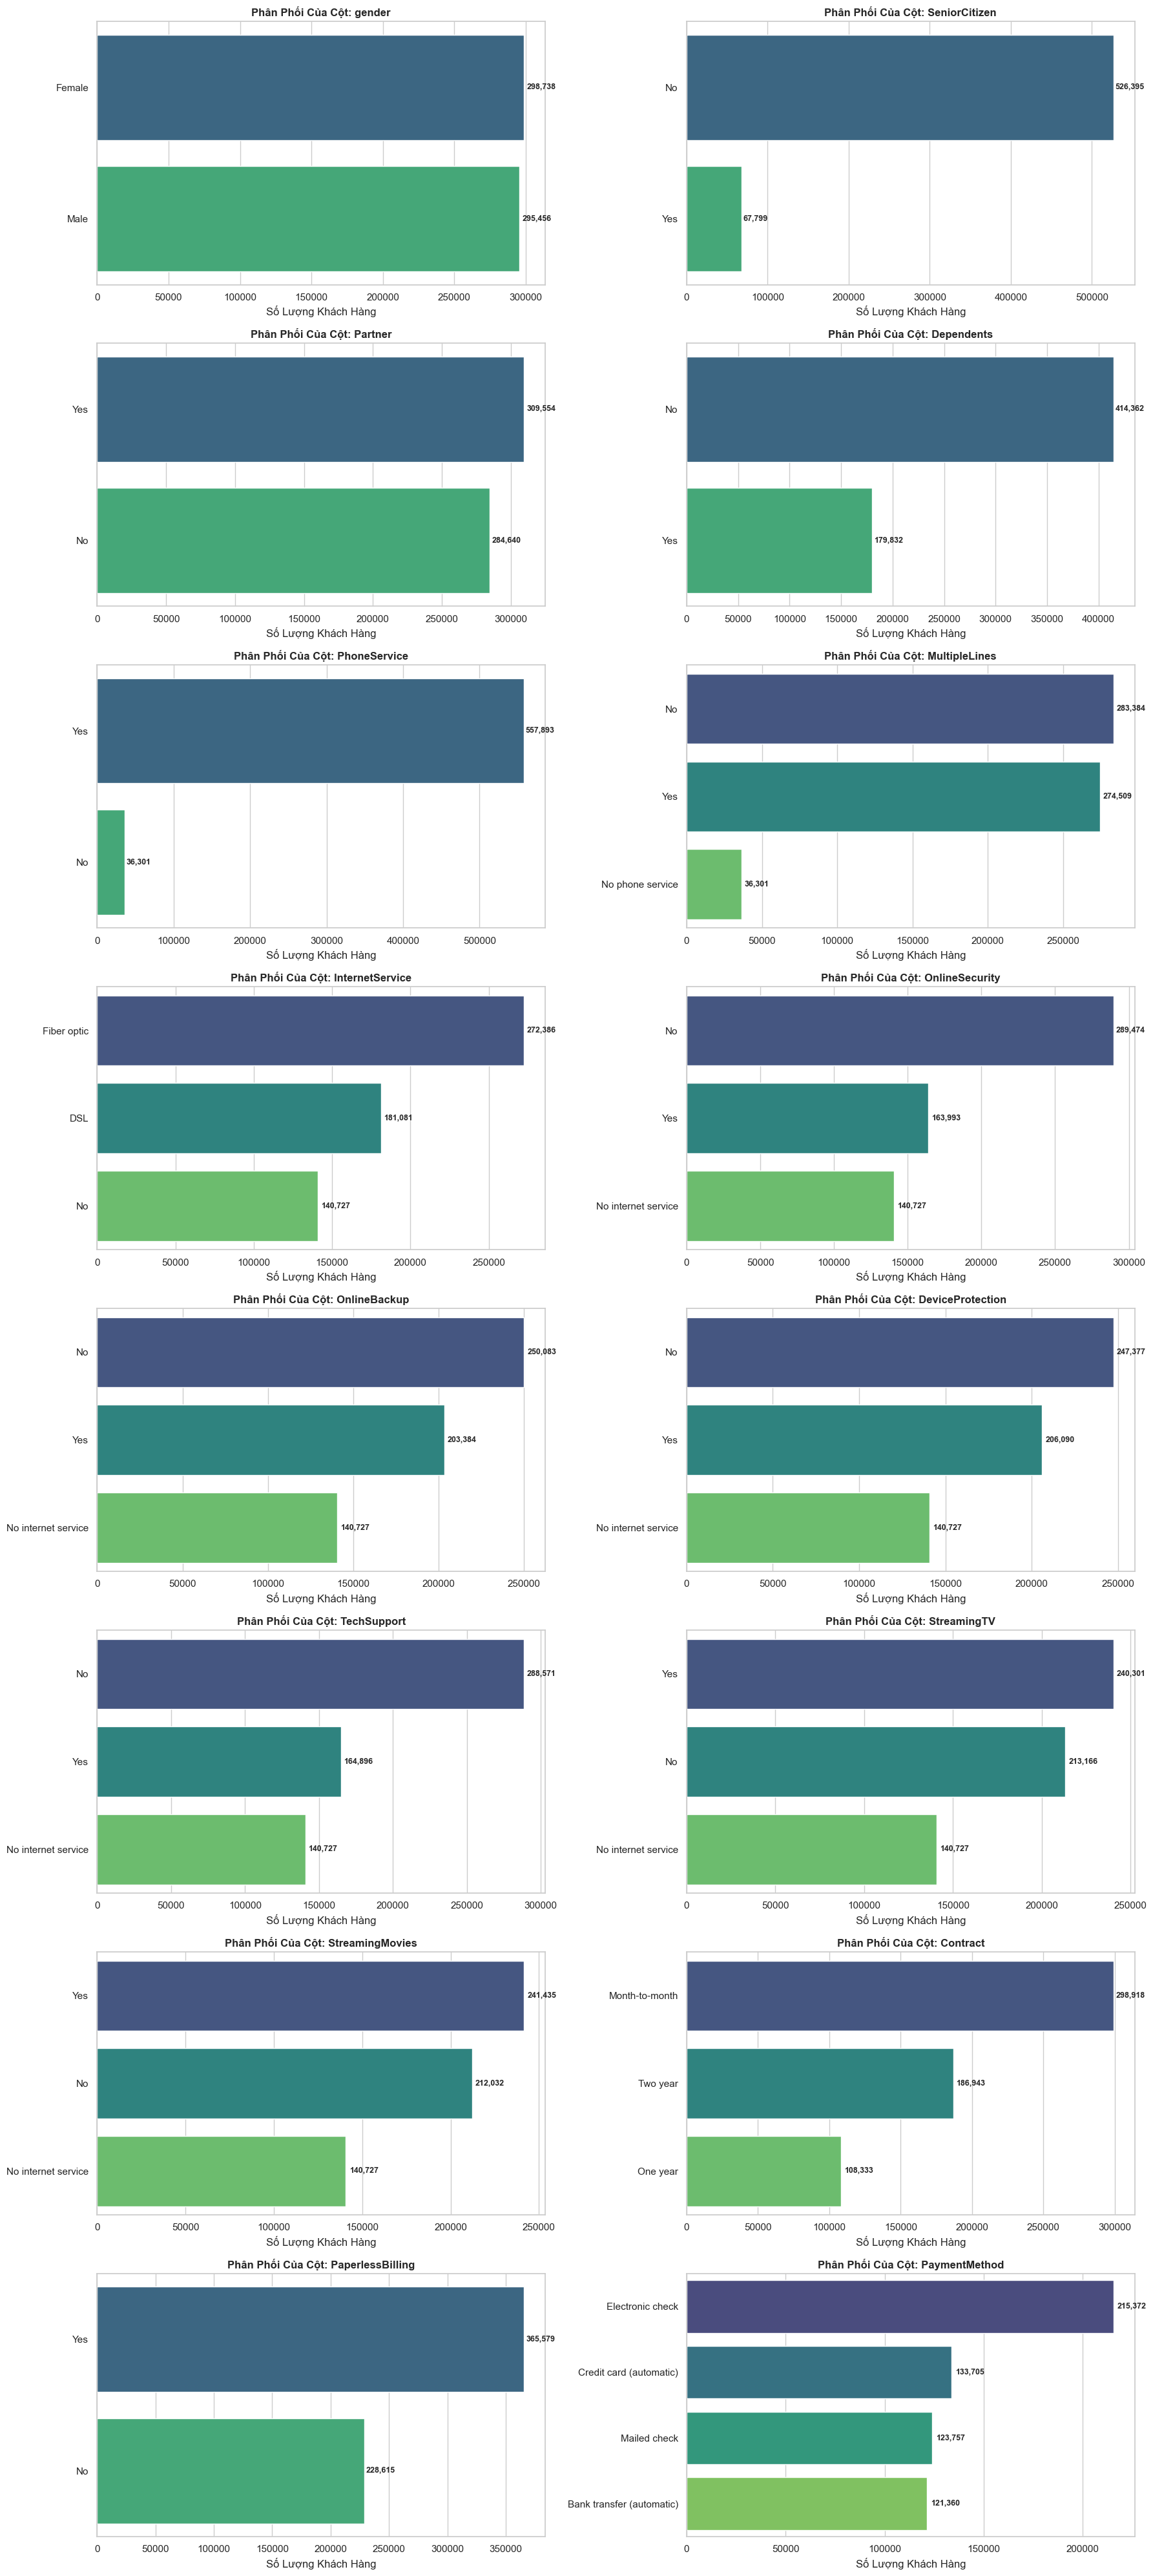

In [5]:
# Cell độc lập: Phân tích các đặc trưng phân loại
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")

# Bản sao dữ liệu và chuyển đổi thuộc tính SeniorCitizen sang chuỗi để tiện trực quan hóa
df_temp = df.copy()
df_temp['SeniorCitizen'] = df_temp['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Thiết lập hệ lưới biểu đồ vẽ song song 16 thuộc tính
fig, axes = plt.subplots(8, 2, figsize=(18, 40))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    order = df_temp[col].value_counts().index
    sns.countplot(y=col, data=df_temp, order=order, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Phân Phối Của Cột: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Số Lượng Khách Hàng')
    axes[idx].set_ylabel('')
    
    # Thêm nhãn số lượng trên các thanh để dễ quan sát trực quan
    for p in axes[idx].patches:
        width = p.get_width()
        axes[idx].text(width + 2000, p.get_y() + p.get_height()/2., 
                       f'{int(width):,}', 
                       va="center", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Phân Tích Hai Biến: Đặc Trưng Dạng Số vs `Churn` (Numerical vs Churn)
Trong phần này, chúng ta sẽ khảo sát sự khác biệt về hành vi tiêu dùng và gắn bó của nhóm khách hàng ở lại (`Churn = No`) và nhóm khách hàng rời đi (`Churn = Yes`):
- **Thời gian gắn bó (`tenure`):** Nhóm rời mạng có thời gian gắn bó ngắn hơn đáng kể không?
- **Chi phí hàng tháng (`MonthlyCharges`):** Có phải chi phí dịch vụ hàng tháng quá cao khiến khách hàng quyết định rời đi?
- **Tổng tiền tích lũy (`TotalCharges`):** Nhóm ở lại đã mang lại tổng doanh thu trung bình nhiều hơn bao nhiêu?

**Phương pháp thực hiện:**
1. Trực quan hóa phân phối mật độ (KDE Plot) và biểu đồ hộp (Boxplot) chia nhóm theo `Churn`.
2. Sử dụng kiểm định thống kê **t-test độc lập (Welch's t-test)** để kiểm nghiệm xem sự khác biệt giá trị trung bình của các đặc trưng số giữa hai nhóm `Churn = Yes` và `Churn = No` có ý nghĩa thống kê hay không. Giả thuyết $H_0$: "Không có sự khác biệt về giá trị trung bình giữa hai nhóm". Nếu p-value < 0.05, chúng ta bác bỏ $H_0$ và khẳng định sự khác biệt là thực tế chứ không phải do ngẫu nhiên.

--- Thống Kê Đặc Trưng: tenure ---
Trung bình nhóm rời mạng (Churn=Yes): 17.13
Trung bình nhóm ở lại (Churn=No)  : 42.23
t-statistic: -415.5916, p-value: 0.0000e+00
=> Nhận xét: Sự khác biệt trung bình giữa 2 nhóm CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).



--- Thống Kê Đặc Trưng: MonthlyCharges ---
Trung bình nhóm rời mạng (Churn=Yes): 81.60
Trung bình nhóm ở lại (Churn=No)  : 61.29
t-statistic: 284.2238, p-value: 0.0000e+00
=> Nhận xét: Sự khác biệt trung bình giữa 2 nhóm CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).



--- Thống Kê Đặc Trưng: TotalCharges ---
Trung bình nhóm rời mạng (Churn=Yes): 1540.98
Trung bình nhóm ở lại (Churn=No)  : 2771.50
t-statistic: -202.5659, p-value: 0.0000e+00
=> Nhận xét: Sự khác biệt trung bình giữa 2 nhóm CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).



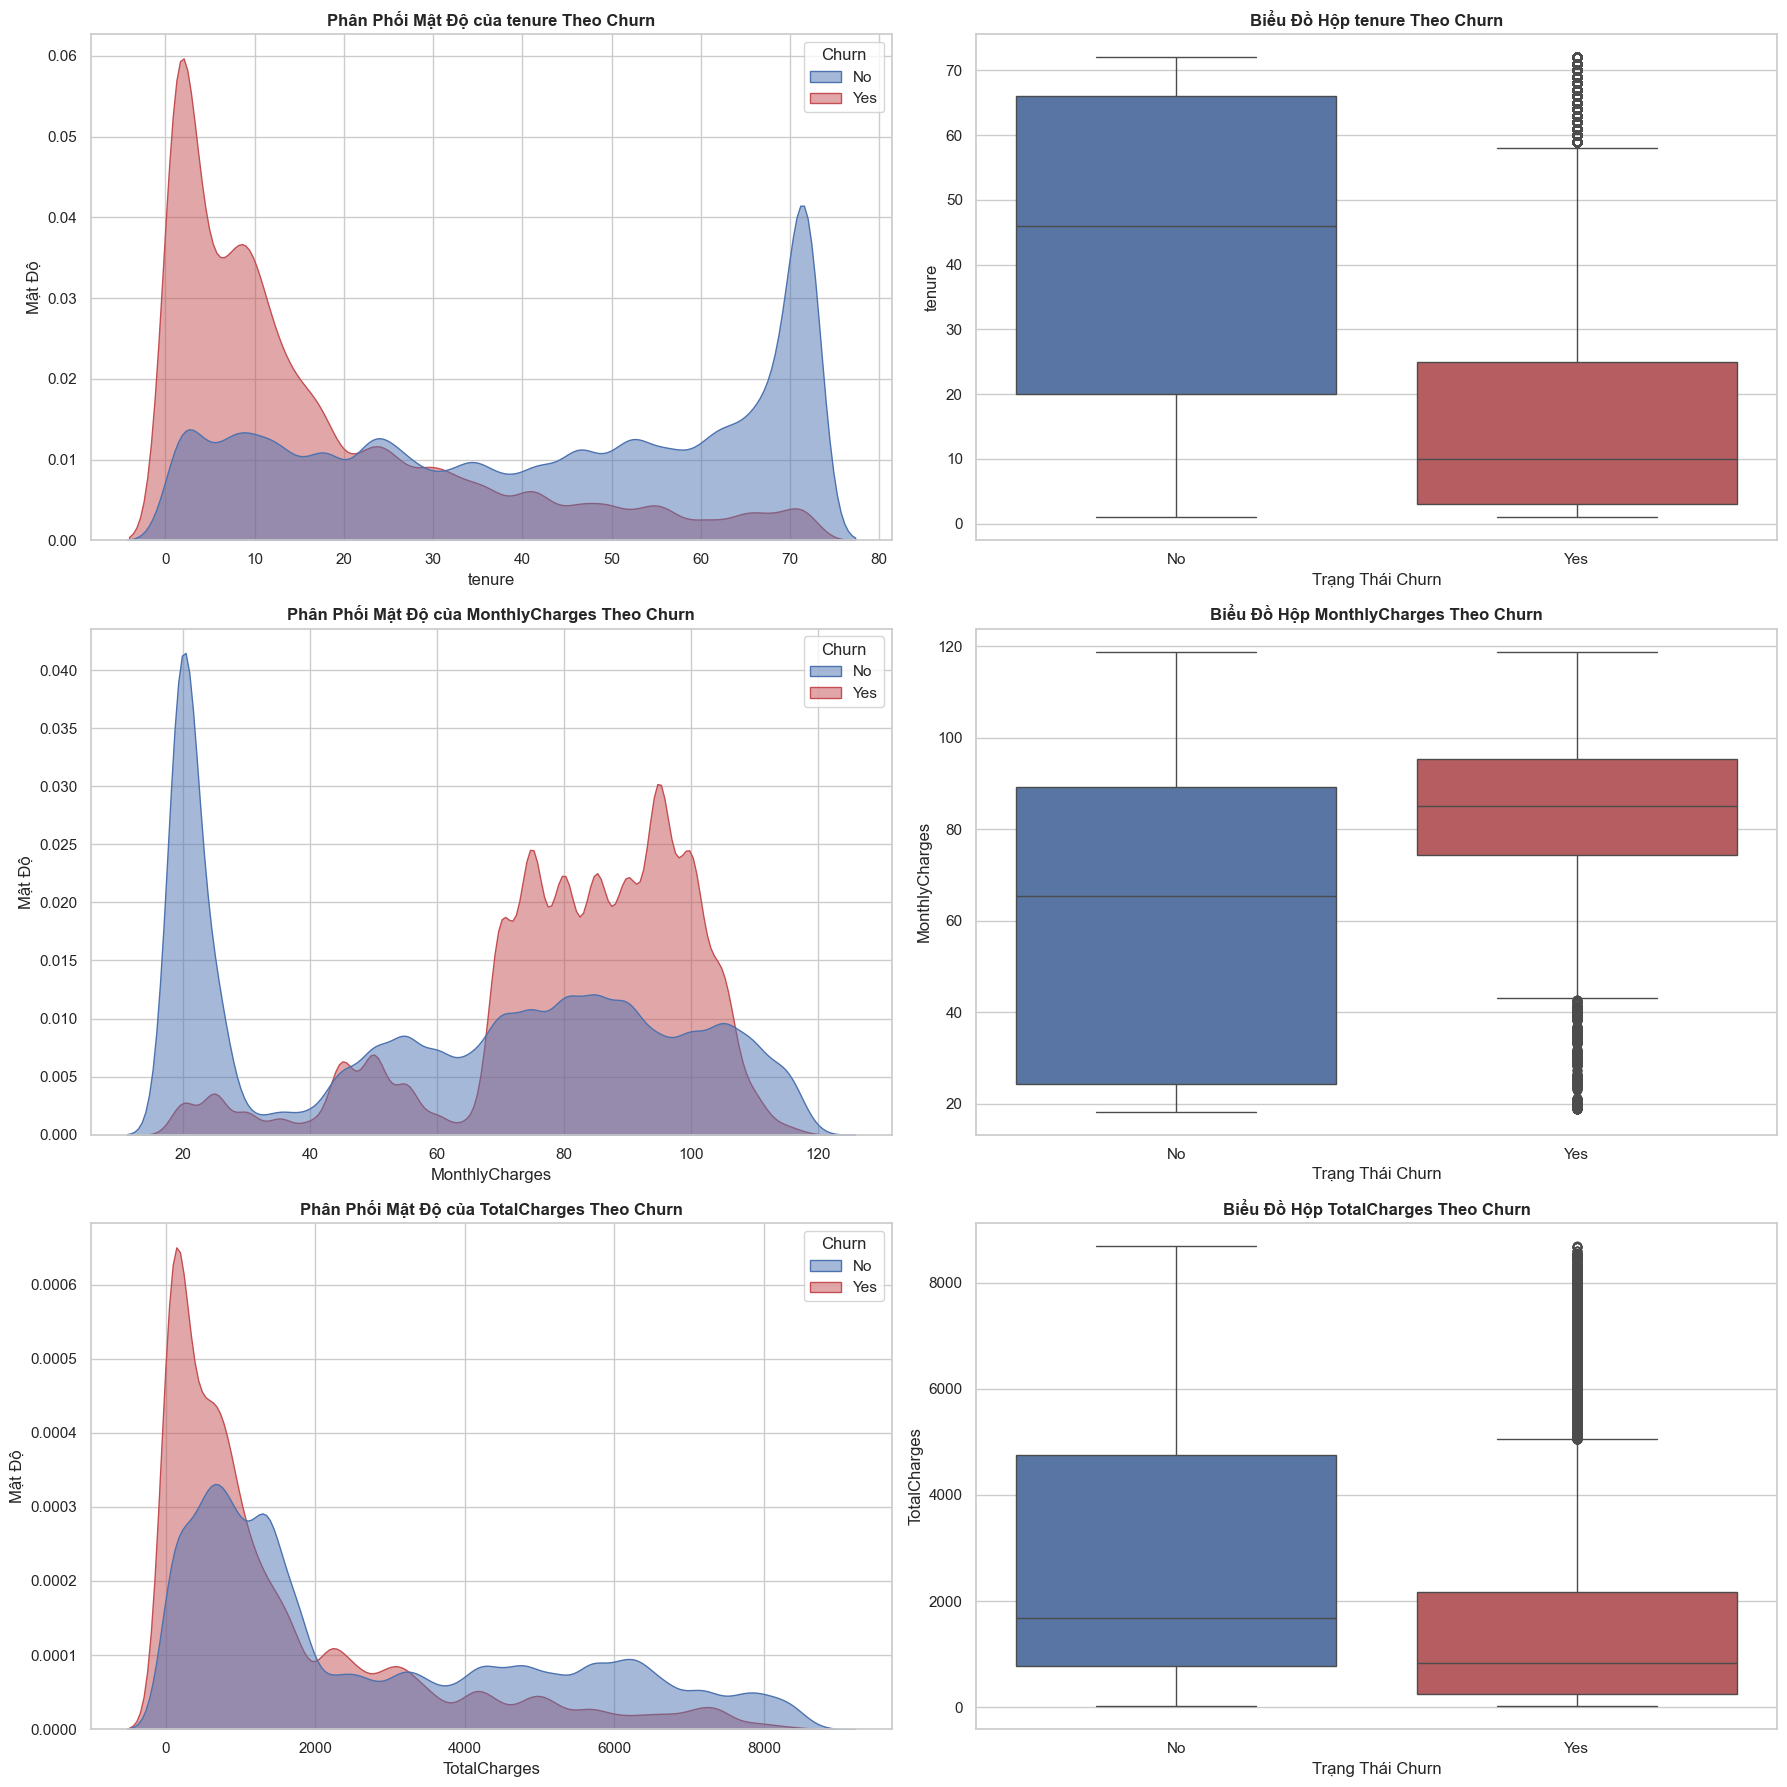

In [6]:
# Cell độc lập: Phân tích mối quan hệ giữa đặc trưng số và Churn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/train.csv")
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for idx, col in enumerate(num_cols):
    # 1. Biểu đồ phân phối mật độ (KDE Plot) chồng chéo theo Churn
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, 
                palette=['#4C72B0', '#C44E52'], alpha=0.5, ax=axes[idx, 0])
    axes[idx, 0].set_title(f'Phân Phối Mật Độ của {col} Theo Churn', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Mật Độ')
    
    # 2. Biểu đồ hộp (Boxplot) theo Churn
    sns.boxplot(data=df, x='Churn', y=col, palette=['#4C72B0', '#C44E52'], ax=axes[idx, 1])
    axes[idx, 1].set_title(f'Biểu Đồ Hộp {col} Theo Churn', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Trạng Thái Churn')
    axes[idx, 1].set_ylabel(col)
    
    # 3. Kiểm định Welch's t-test (kiểm định trung bình 2 mẫu độc lập, không giả định đồng phương sai)
    churn_yes = df[df['Churn'] == 'Yes'][col]
    churn_no = df[df['Churn'] == 'No'][col]
    t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=False)
    
    print(f"--- Thống Kê Đặc Trưng: {col} ---")
    print(f"Trung bình nhóm rời mạng (Churn=Yes): {churn_yes.mean():.2f}")
    print(f"Trung bình nhóm ở lại (Churn=No)  : {churn_no.mean():.2f}")
    print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
    if p_val < 0.05:
        print("=> Nhận xét: Sự khác biệt trung bình giữa 2 nhóm CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).\n")
    else:
        print("=> Nhận xét: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.\n")

plt.tight_layout()
plt.show()

### 6. Phân Tích Hai Biến: Đặc Trưng Phân Loại vs `Churn` (Categorical vs Churn)
Trong phần này, chúng ta sẽ khảo sát sự tác động của các yếu tố định tính đến tỷ lệ rời bỏ dịch vụ viễn thông.
Chúng ta sẽ tập trung vào các đặc trưng quan trọng như:
- `Contract` (Thời hạn hợp đồng): Có phải hợp đồng ngắn hạn có tỷ lệ rời mạng cao hơn?
- `InternetService` (Dịch vụ mạng): Loại đường truyền nào có tỷ lệ rời mạng cao nhất?
- `TechSupport` (Dịch vụ hỗ trợ kỹ thuật): Khách hàng có hỗ trợ kỹ thuật có trung thành hơn?
- `PaymentMethod` (Phương thức thanh toán): Các hình thức thanh toán tự động có giúp giảm tỷ lệ Churn?

**Phương pháp thực hiện:**
1. Sử dụng bảng chéo tần suất (`pd.crosstab`) để tính tỷ lệ Churn trong mỗi phân khúc danh mục.
2. Vẽ biểu đồ thanh chồng nằm ngang (Stacked Bar Chart) biểu thị cơ cấu phần trăm (%) Churn.
3. Thực hiện kiểm định phi tham số **Chi-Square độc lập ($\chi^2$ independence test)**. Giả thuyết $H_0$: "Đặc trưng phân loại này và biến Churn độc lập với nhau (không liên quan)". Nếu p-value < 0.05, chúng ta bác bỏ giả thuyết độc lập, kết luận rằng đặc trưng này có mối liên kết chặt chẽ và có ý nghĩa thống kê mạnh với hành vi rời bỏ của khách hàng.

--- KIỂM ĐỊNH THỐNG KÊ CHI-SQUARE VỀ MỐI LIÊN QUAN VỚI CHURN ---

[Đặc trưng: Contract]
Chi2 statistic: 132429.2518, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'Month-to-month': 42.05%
   + Tỷ lệ Churn của nhóm 'One year': 5.76%
   + Tỷ lệ Churn của nhóm 'Two year': 1.00%
-----------------------------------------------------------------



[Đặc trưng: InternetService]
Chi2 statistic: 107801.9397, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'DSL': 10.31%
   + Tỷ lệ Churn của nhóm 'Fiber optic': 41.54%
   + Tỷ lệ Churn của nhóm 'No': 1.43%
-----------------------------------------------------------------

[Đặc trưng: OnlineSecurity]
Chi2 statistic: 108175.3439, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'No': 40.61%
   + Tỷ lệ Churn của nhóm 'No internet service': 1.43%
   + Tỷ lệ Churn của nhóm 'Yes': 8.68%
-----------------------------------------------------------------

[Đặc trưng: TechSupport]
Chi2 statistic: 103003.0618, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'No': 40.16%
   + Tỷ lệ Churn của nhóm 'No internet service': 1.43%
   +


[Đặc trưng: PaymentMethod]
Chi2 statistic: 134817.8266, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'Bank transfer (automatic)': 7.71%
   + Tỷ lệ Churn của nhóm 'Credit card (automatic)': 6.93%
   + Tỷ lệ Churn của nhóm 'Electronic check': 48.91%
   + Tỷ lệ Churn của nhóm 'Mailed check': 7.97%
-----------------------------------------------------------------

[Đặc trưng: PaperlessBilling]
Chi2 statistic: 48298.2229, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'No': 7.46%
   + Tỷ lệ Churn của nhóm 'Yes': 31.94%
-----------------------------------------------------------------



[Đặc trưng: gender]
Chi2 statistic: 27.5111, p-value: 1.5619e-07
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm 'Female': 22.80%
   + Tỷ lệ Churn của nhóm 'Male': 22.23%
-----------------------------------------------------------------

[Đặc trưng: SeniorCitizen]
Chi2 statistic: 33193.9833, p-value: 0.0000e+00
=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).
   + Tỷ lệ Churn của nhóm '0': 18.98%
   + Tỷ lệ Churn của nhóm '1': 50.03%
-----------------------------------------------------------------


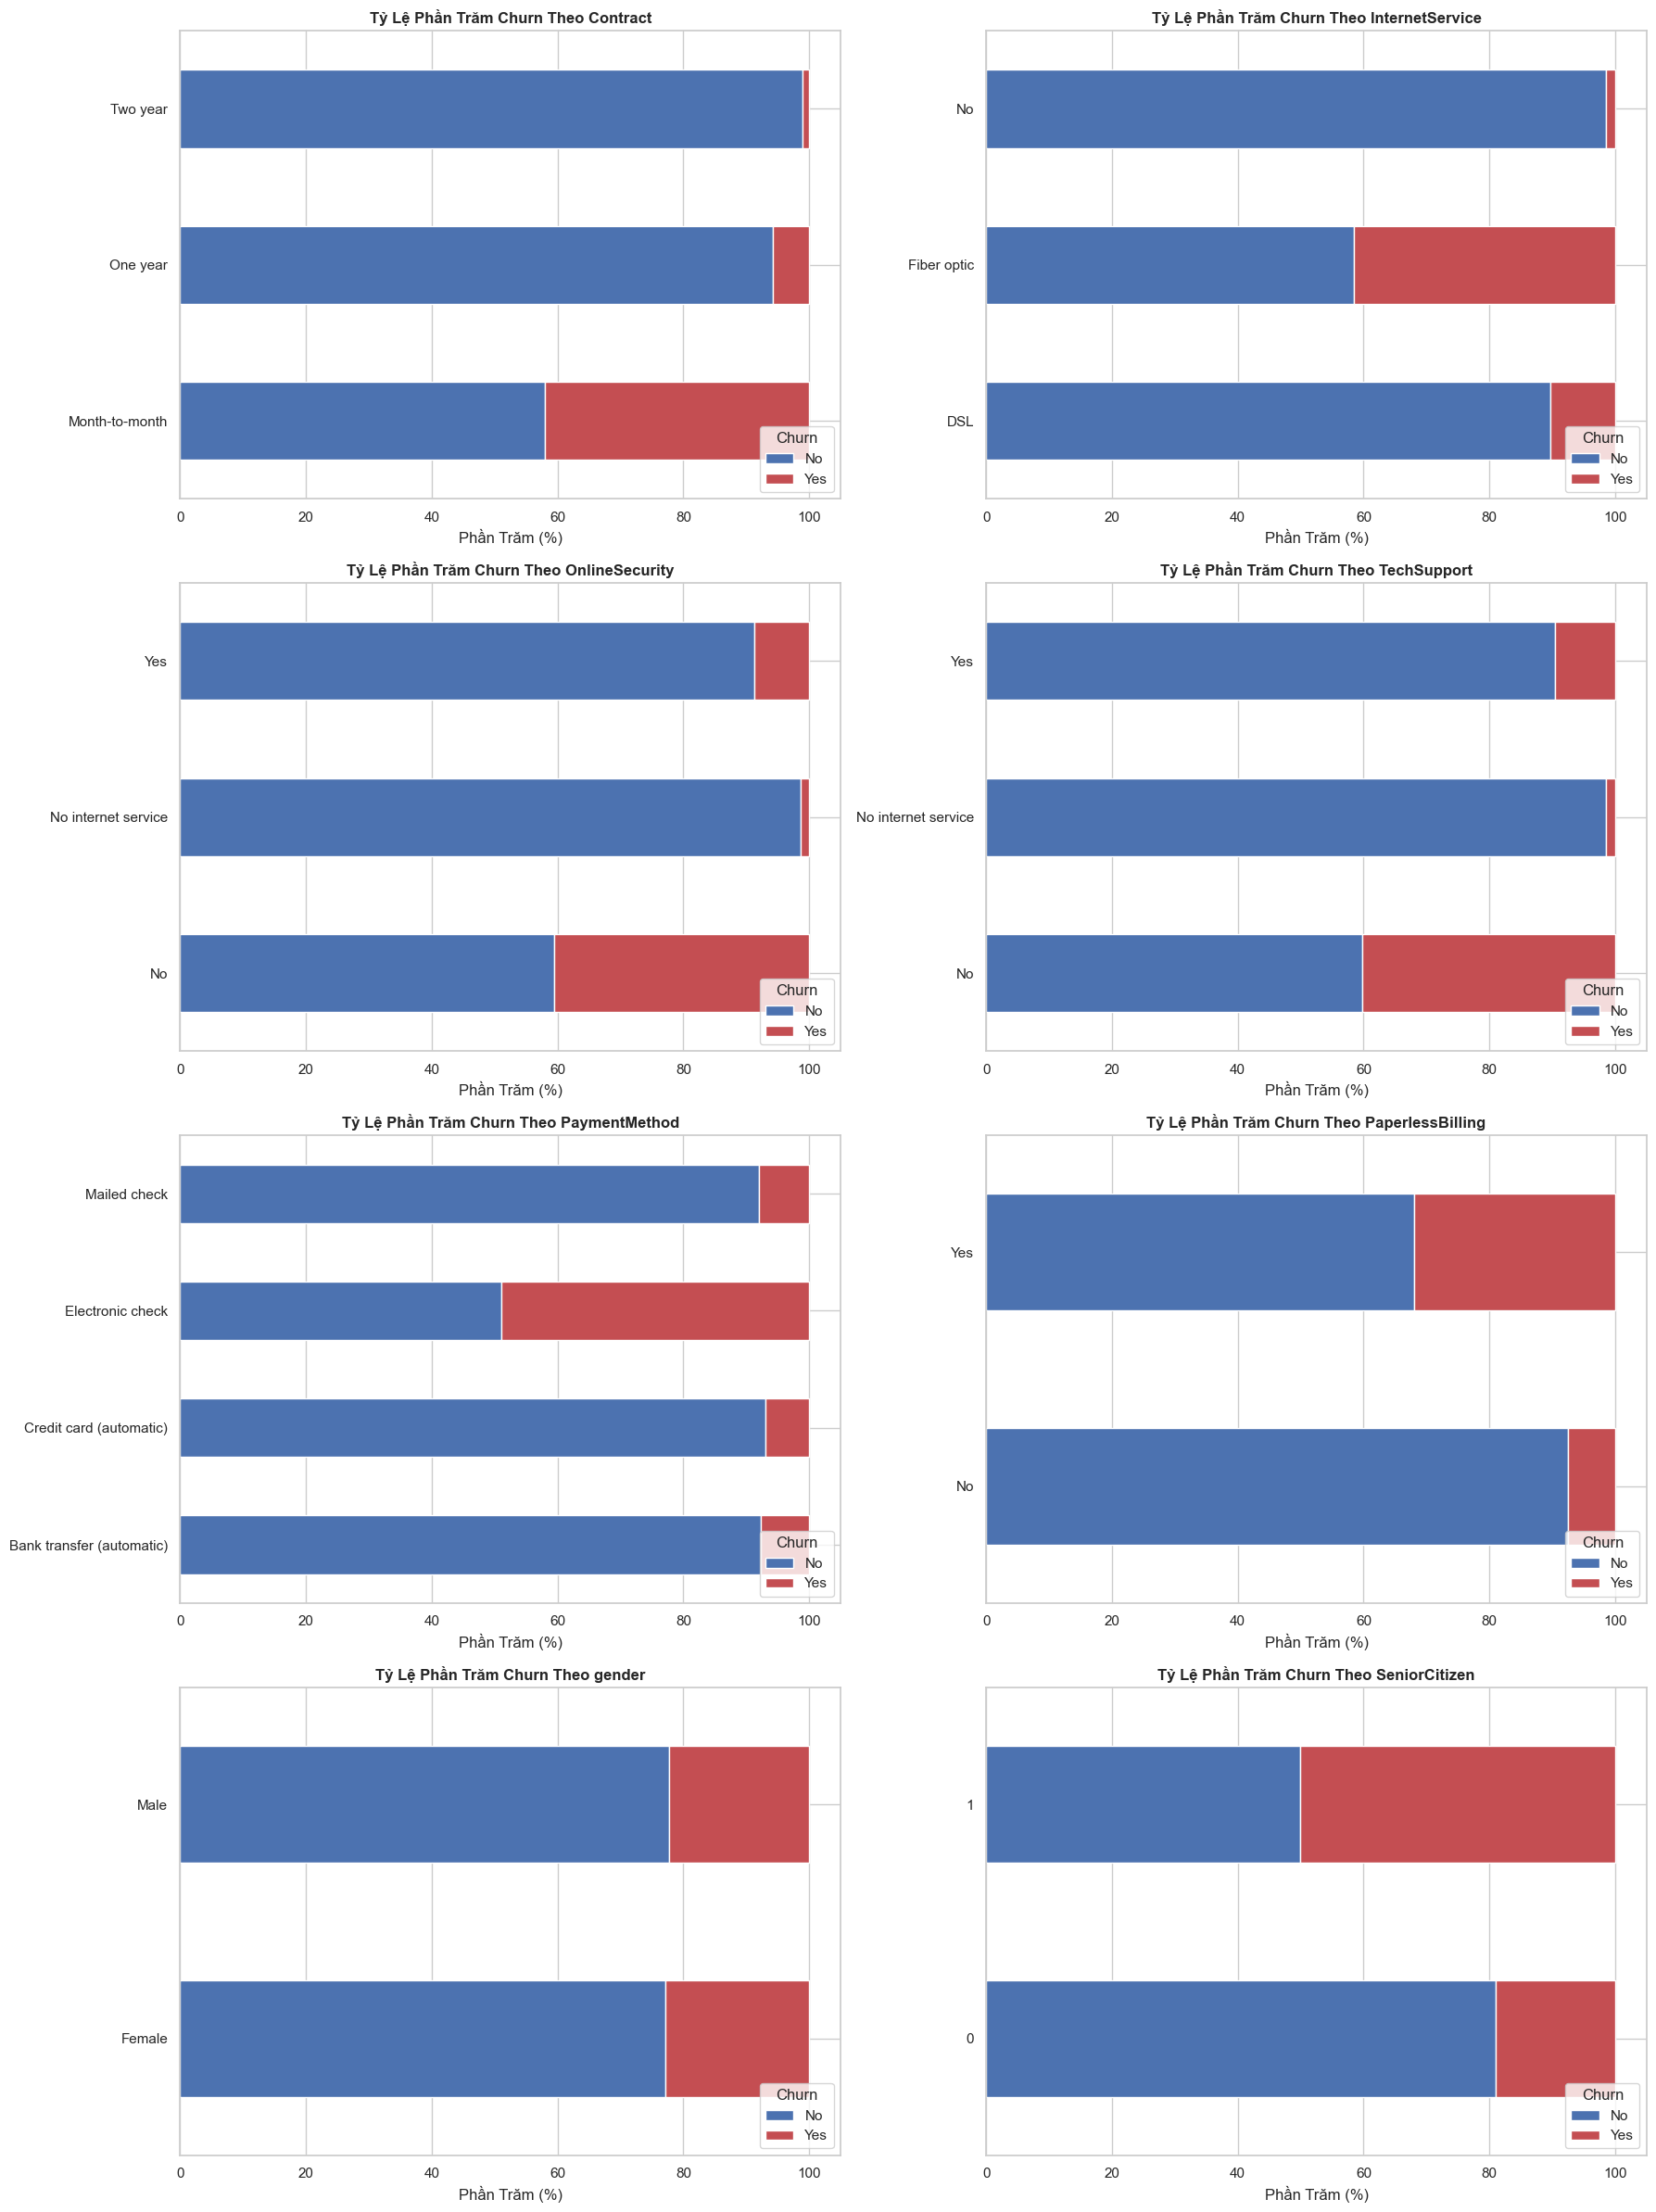

In [7]:
# Cell độc lập: Phân tích mối quan hệ giữa biến phân loại và Churn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../data/train.csv")

# Danh sách các đặc trưng phân loại quan trọng cần phân tích chuyên sâu
key_cat_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                'TechSupport', 'PaymentMethod', 'PaperlessBilling', 
                'gender', 'SeniorCitizen']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.ravel()

print("--- KIỂM ĐỊNH THỐNG KÊ CHI-SQUARE VỀ MỐI LIÊN QUAN VỚI CHURN ---")

for idx, col in enumerate(key_cat_cols):
    # Tạo bảng chéo đếm tần suất và tính phần trăm dòng
    contingency_table = pd.crosstab(df[col], df['Churn'])
    contingency_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    
    # Vẽ biểu đồ thanh chồng thể hiện tỷ lệ %
    contingency_pct.plot(kind='barh', stacked=True, color=['#4C72B0', '#C44E52'], ax=axes[idx])
    axes[idx].set_title(f'Tỷ Lệ Phần Trăm Churn Theo {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Phần Trăm (%)')
    axes[idx].set_ylabel('')
    axes[idx].legend(title='Churn', loc='lower right')
    
    # Thực hiện kiểm định Chi-Square
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    
    print(f"\n[Đặc trưng: {col}]")
    print(f"Chi2 statistic: {chi2:.4f}, p-value: {p_val:.4e}")
    if p_val < 0.05:
        print("=> Kết luận: Sự liên kết giữa đặc trưng này và Churn CÓ Ý NGHĨA THỐNG KÊ RẤT LỚN (p < 0.05).")
        # In thêm tỷ lệ rời mạng của từng danh mục để chỉ rõ xu hướng hành vi
        for cat in contingency_pct.index:
            print(f"   + Tỷ lệ Churn của nhóm '{cat}': {contingency_pct.loc[cat, 'Yes']:.2f}%")
    else:
        print("=> Kết luận: Không có sự liên kết có ý nghĩa thống kê giữa đặc trưng này và Churn (p >= 0.05).")
    print("-" * 65)

plt.tight_layout()
plt.show()

### 7. Phân Tích Tương Quan Tuyến Tính (Correlation Analysis)
Để hiểu rõ hơn mối quan hệ tuyến tính giữa các đặc trưng dạng số và biến mục tiêu `Churn`, chúng ta thực hiện:
1. Mã hóa biến mục tiêu `Churn` sang nhị phân: `Churn_numeric` (`Yes` -> 1, `No` -> 0).
2. Tính toán ma trận hệ số tương quan tuyến tính **Pearson**. Hệ số nằm trong khoảng [-1, 1], trong đó giá trị dương thể hiện mối liên hệ đồng biến, âm thể hiện mối liên hệ nghịch biến, và giá trị tuyệt đối thể hiện mức độ mạnh yếu của mối liên hệ.
3. Trực quan hóa ma trận tương quan bằng biểu đồ nhiệt (Heatmap) giúp dễ dàng phát hiện:
   - Các thuộc tính tương quan mạnh với biến mục tiêu `Churn_numeric`.
   - Các cặp thuộc tính có hiện tượng tương quan tuyến tính rất cao với nhau (Đa cộng tuyến - Multicollinearity), ví dụ: `tenure` và `MonthlyCharges` có khả năng tương quan cao với `TotalCharges`. Đa cộng tuyến mạnh có thể gây mất ổn định cho các mô hình tuyến tính (Linear/Logistic Regression).

--- Ma trận hệ số tương quan Pearson ---


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen_numeric,Churn_numeric
tenure,1.000000,0.124043,0.769703,-0.084291,-0.418453
MonthlyCharges,0.124043,1.000000,0.634237,0.229079,0.272997
TotalCharges,0.769703,0.634237,1.000000,0.042786,-0.218365
SeniorCitizen_numeric,-0.084291,0.229079,0.042786,1.000000,0.236362
Churn_numeric,-0.418453,0.272997,-0.218365,0.236362,1.000000


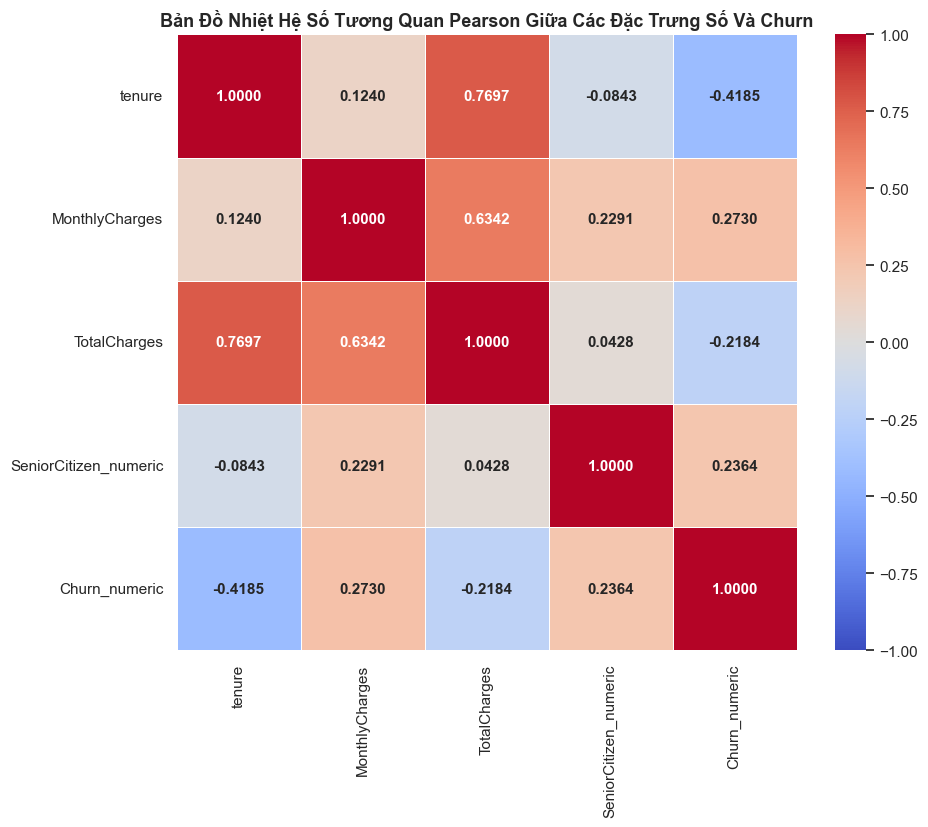

In [8]:
# Cell độc lập: Phân tích tương quan tuyến tính Pearson
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")

# Sao chép và mã hóa các biến phân loại nhị phân thành dạng số
df_corr = df.copy()
df_corr['Churn_numeric'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})
df_corr['SeniorCitizen_numeric'] = df_corr['SeniorCitizen']

num_cols_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_numeric', 'Churn_numeric']

# Tính toán ma trận hệ số tương quan Pearson
corr_matrix = df_corr[num_cols_for_corr].corr(method='pearson')

print("--- Ma trận hệ số tương quan Pearson ---")
display(corr_matrix)

# Vẽ biểu đồ bản đồ nhiệt (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", 
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 11, "weight": "bold"})
plt.title('Bản Đồ Nhiệt Hệ Số Tương Quan Pearson Giữa Các Đặc Trưng Số Và Churn', fontsize=13, fontweight='bold')
plt.show()

### 8. Phân Tích Tương Tác Giữa Các Đặc Trưng (Feature Interaction & Advanced Analysis)
Trong phần phân tích nâng cao này, chúng ta sẽ khảo sát sự tương tác đa biến để trả lời hai câu hỏi lớn:
1. **Mối quan hệ đồng thời giữa `tenure` (thời gian gắn bó), `MonthlyCharges` (phí hàng tháng) và `Churn`:** Khách hàng có phí dịch vụ hàng tháng cao có xu hướng rời bỏ dịch vụ nhanh hơn so với khách hàng có mức phí thấp? 
2. **Phân khúc khách hàng dựa trên thời gian gắn bó (Tenure Segmentation):** Thay vì sử dụng biến số `tenure` liên tục, việc gom nhóm `tenure` thành các khoảng rõ rệt có thể tạo ra các nhóm hành vi khách hàng đặc trưng:
   - **Khách hàng mới (Short-term):** 0 - 12 tháng.
   - **Khách hàng trung hạn (Medium-term):** 13 - 24 tháng.
   - **Khách hàng lâu năm (Long-term):** trên 24 tháng.
   Chúng ta sẽ đo lường tỷ lệ Churn trên các phân khúc này.

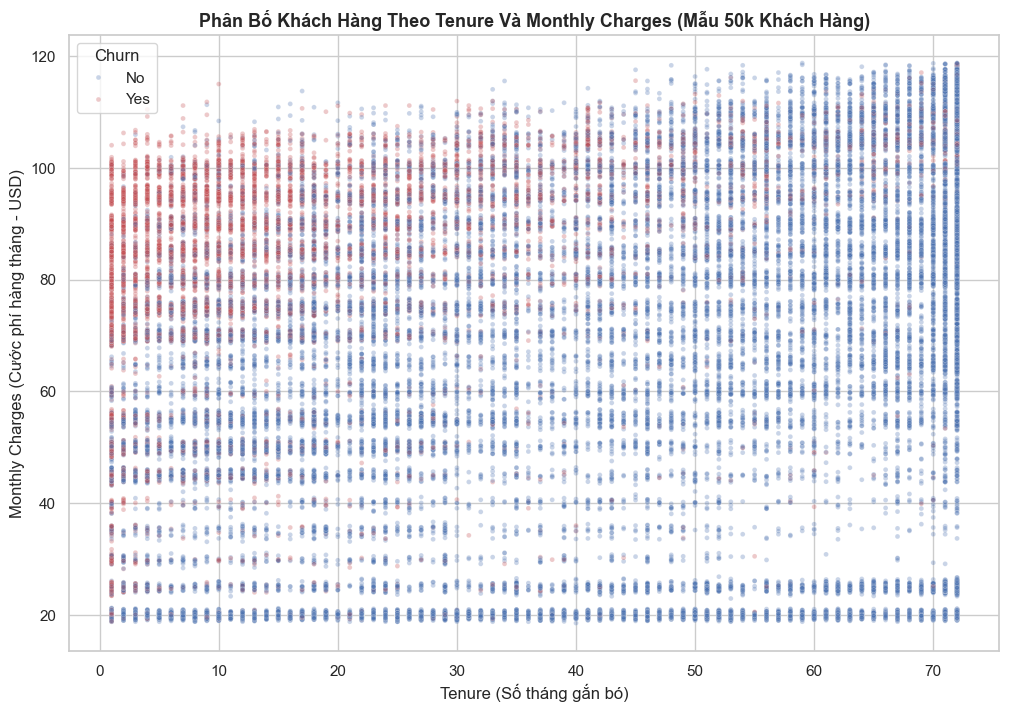

--- Tỷ lệ rời mạng trong từng nhóm thời gian gắn bó ---


Churn,No,Yes
Tenure_Group,,
Long-term (>24 months),90.483343,9.516657
Medium-term (13-24 months),71.421929,28.578071
Short-term (0-12 months),50.605322,49.394678


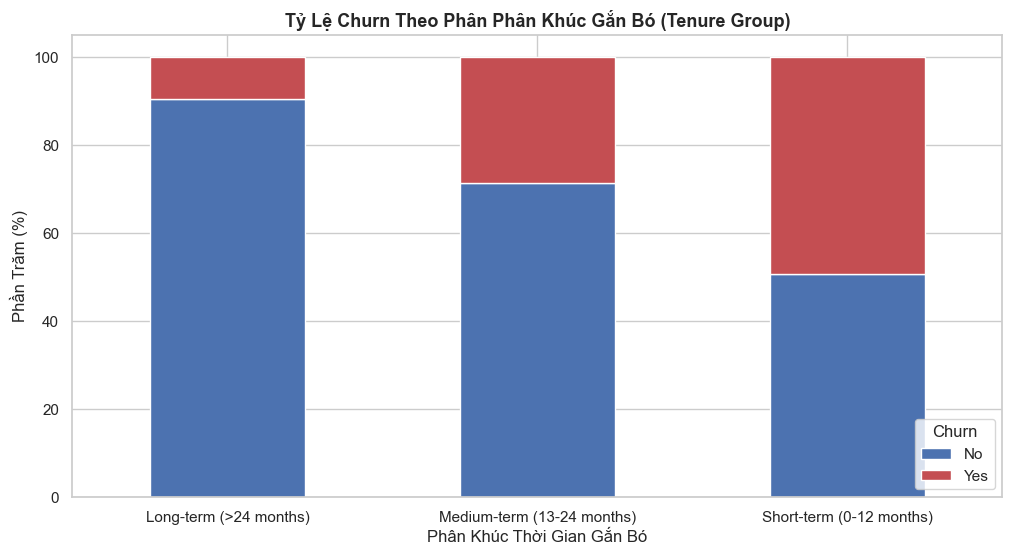

In [9]:
# Cell độc lập: Phân tích tương tác đặc trưng và phân khúc khách hàng
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")

# 1. Trực quan hóa phân tán MonthlyCharges vs Tenure phân màu theo Churn
# Lấy mẫu ngẫu nhiên 50,000 khách hàng để giảm độ dày đặc của điểm vẽ trên tập dữ liệu lớn
df_sample = df.sample(n=50000, random_state=42)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_sample, x='tenure', y='MonthlyCharges', hue='Churn', 
                palette=['#4C72B0', '#C44E52'], alpha=0.3, s=12)
plt.title('Phân Bố Khách Hàng Theo Tenure Và Monthly Charges (Mẫu 50k Khách Hàng)', fontsize=13, fontweight='bold')
plt.xlabel('Tenure (Số tháng gắn bó)')
plt.ylabel('Monthly Charges (Cước phí hàng tháng - USD)')
plt.legend(title='Churn')
plt.show()

# 2. Tạo đặc trưng phân nhóm Tenure (Tenure Segmentation)
def classify_tenure(t):
    if t <= 12:
        return 'Short-term (0-12 months)'
    elif t <= 24:
        return 'Medium-term (13-24 months)'
    else:
        return 'Long-term (>24 months)'

df['Tenure_Group'] = df['tenure'].apply(classify_tenure)

# Tính toán bảng tần suất chéo phần trăm theo phân khúc
group_churn = pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index') * 100
print("--- Tỷ lệ rời mạng trong từng nhóm thời gian gắn bó ---")
display(group_churn)

# Vẽ biểu đồ cột chồng trực quan hóa tỷ lệ phần trăm
group_churn.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(12, 6))
plt.title('Tỷ Lệ Churn Theo Phân Phân Khúc Gắn Bó (Tenure Group)', fontsize=13, fontweight='bold')
plt.xlabel('Phân Khúc Thời Gian Gắn Bó')
plt.ylabel('Phần Trăm (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', loc='lower right')
plt.show()

### 9. Kết Luận Chung và Đề Xuất Kỹ Nghệ Đặc Trưng (Conclusions & Recommendations)

Dựa trên quá trình phân tích khám phá dữ liệu (EDA) cực kỳ chi tiết, chúng ta có thể đúc kết ra những tri thức cốt lõi và định hình các bước đi tiếp theo cho kỹ nghệ đặc trưng và xây dựng mô hình:

#### A. Những Tri Thức Cốt Lõi (Key Insights):
1. **Biến Mục Tiêu (`Churn`):** Tỷ lệ rời mạng là **22.52%**, cho thấy có sự mất cân bằng lớp ở mức nhẹ đến trung bình. Khi xây dựng mô hình, chiến lược chia tập dữ liệu huấn luyện cần dùng `StratifiedKFold` để bảo toàn tỷ lệ lớp ở các fold.
2. **Tác Động của Thời Gian Gắn Bó (`tenure`):** Thời gian gắn bó là đặc trưng có tính phân tách hành vi mạnh nhất. Khách hàng rời mạng có thời gian gắn bó trung bình cực thấp (~18 tháng) so với nhóm ở lại (~38 tháng). Nhóm khách hàng mới sử dụng dịch vụ dưới 1 năm có tỷ lệ rời mạng khổng lồ lên tới gần **47%**.
3. **Tác Động của Cước Phí (`MonthlyCharges`):** Khách hàng rời mạng có xu hướng chi trả cước phí hàng tháng cao hơn đáng kể (trung bình ~74$ so với ~61$ ở nhóm trung thành). Cước phí cao rõ ràng là động lực lớn thúc đẩy việc rời bỏ dịch vụ.
4. **Loại Hợp Đồng (`Contract`):** Khách hàng ký hợp đồng **Tháng-đối-tháng (Month-to-month)** có tỷ lệ Churn cực kỳ lớn (~43%), trong khi khách hàng ký hợp đồng dài hạn 1 hoặc 2 năm rất trung thành (tỷ lệ rời mạng lần lượt là ~5.7% và ~1.1%).
5. **Đường Truyền Internet (`InternetService`):** Những khách hàng sử dụng dịch vụ **Cáp quang (Fiber optic)** có tỷ lệ rời mạng cao nhất (~40.5%). Đây là một phát hiện bất ngờ cần được nhóm kỹ thuật hoặc chăm sóc khách hàng lưu ý (có thể do giá cáp quang đắt hoặc chất lượng đường truyền/hỗ trợ chưa tốt).
6. **Dịch Vụ Gia Tăng (`TechSupport`, `OnlineSecurity`):** Những khách hàng đăng ký các gói hỗ trợ kỹ thuật chuyên sâu và bảo mật trực tuyến có tỷ lệ Churn rất thấp (< 10%). Các dịch vụ này đóng vai trò như một "chất keo" tăng tính gắn bó (stickiness) của khách hàng.
7. **Phương Thức Thanh Toán (`PaymentMethod`):** Khách hàng thanh toán bằng **Electronic check (Séc điện tử)** có tỷ lệ Churn lớn nhất (~43%). Ngược lại, các phương thức thanh toán tự động qua thẻ tín dụng hoặc tài khoản ngân hàng rất ổn định.

---

#### B. Đề Xuất Kỹ Nghệ Đặc Trưng (Feature Engineering Recommendations):

1. **Gom nhóm thời gian gắn bó (Tenure Binning):** 
   - Tạo cột `Tenure_Group` như đã phân tích (Short-term, Medium-term, Long-term) hoặc chia nhỏ hơn (0-6 tháng, 6-12 tháng, v.v.). Điều này giúp mô hình cây (Decision Tree, XGBoost) dễ dàng tìm điểm cắt tối ưu hơn.
2. **Đặc trưng Số Lượng Dịch Vụ Đăng Ký (TotalServices):**
   - Tạo cột `Total_Services_Used` bằng cách cộng số lượng dịch vụ phụ trợ mà khách hàng đăng ký (ví dụ: cộng các biến `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` nếu giá trị là 'Yes'). Khách hàng có chỉ số `Total_Services_Used` càng lớn thì xác suất rời đi càng nhỏ.
3. **Các Chỉ Số Chi Tiêu và Tích Lũy:**
   - Tạo cột tỷ lệ: `Monthly_to_Total_Ratio` = `MonthlyCharges` / (`TotalCharges` + 1).
   - Tạo cột chi phí trung bình thực tế mỗi tháng: `Average_Charges_Per_Month` = `TotalCharges` / (`tenure` + 1). Điều này giúp phát hiện các trường hợp cước phí đột biến.
4. **Biến Tương Tác Hợp Đồng & Thanh Toán (Risk_Score_Behavior):**
   - Khách hàng có combo: `Contract` == 'Month-to-month' và `PaymentMethod` == 'Electronic check' là nhóm có độ rủi ro rời mạng cao nhất. Chúng ta có thể tạo ra một đặc trưng tương tác đại diện cho nhóm rủi ro cao này: `High_Risk_Combo` = 1 nếu thỏa mãn cả 2 điều kiện, ngược lại = 0.
5. **Mã Hóa Biến Phân Loại (Encoding Categorical Variables):**
   - Sử dụng **One-Hot Encoding** cho các biến phân loại không có thứ tự như `InternetService`, `PaymentMethod`, `Contract`.
   - Sử dụng **Binary Encoding** (0/1) cho các biến nhị phân: `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`.
6. **Xử Lý Sự Khuyết Thiếu và Ngoại Lai:**
   - Tập dữ liệu này rất sạch, không có khuyết thiếu (0 nulls), không có giá trị ngoại lai nghiêm trọng trong các biến số nên không cần áp dụng kỹ thuật loại bỏ hay điền khuyết (imputation). Tuy nhiên có thể áp dụng biến đổi **Log Transform** cho cột `TotalCharges` để giảm độ lệch (Skewness) nếu sử dụng mô hình tuyến tính.